# Day 13–14: Transfer Learning with ResNet18

In the previous experiments, I built and trained convolutional neural networks from scratch for CIFAR-10 classification.

In this experiment, I want to test whether starting from a model that has already learned useful visual features can give better results with less training.

For this, I will use ResNet18 pretrained on ImageNet and fine-tune it for the 10 CIFAR-10 classes.

The main things I want to compare are:

- Classification performance
- Training time
- Data efficiency
- Model size
- Performance compared with my from-scratch CNN

The goal is not only to get a higher accuracy, but to understand when transfer learning is actually useful.

## 1. Experiment Overview

CIFAR-10 contains 10 image classes:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

The original CIFAR-10 images are only 32×32 pixels. Since ResNet18 was originally trained on ImageNet images, I will resize the images to 224×224 and use ImageNet normalization.

I will first fine-tune ResNet18 using the complete training set.

After that, I will repeat the experiment using smaller portions of the training data to understand data efficiency.

In [61]:
# Import Libraries

import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [62]:
# Configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

BATCH_SIZE = 64
EPOCHS = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

NUM_CLASSES = 10
NUM_WORKERS = 2

DATA_DIR = "../data"
RESULTS_DIR = "../results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Device:", device)
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning Rate:", LEARNING_RATE)

Device: mps
Batch Size: 64
Epochs: 8
Learning Rate: 0.0001


In [63]:
# Load CIFAR-10

train_raw = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True
)

test_raw = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True
)

class_names = train_raw.classes

print("Training Samples:", len(train_raw))
print("Test Samples:", len(test_raw))
print("Classes:", class_names)

Training Samples: 50000
Test Samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


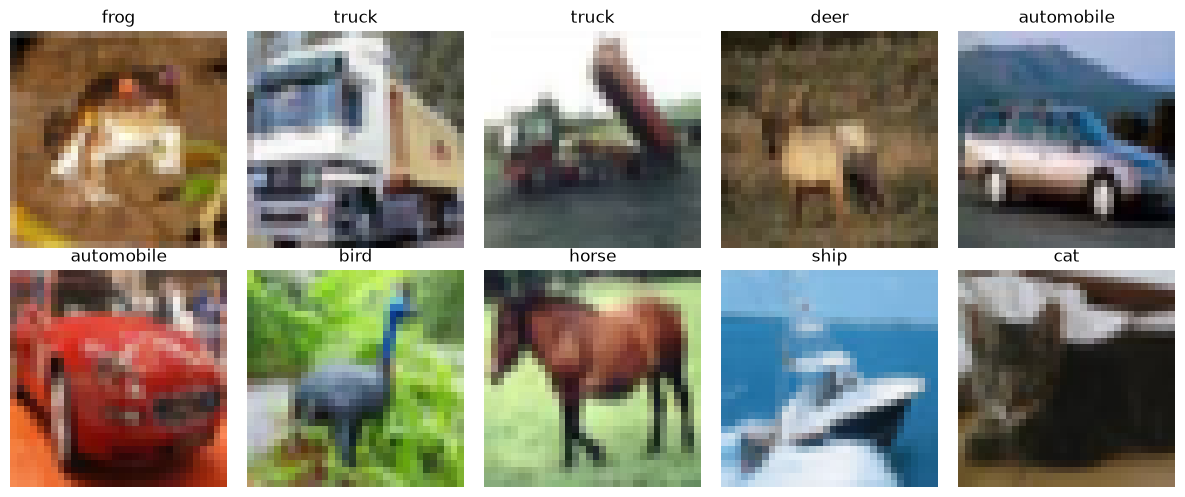

In [64]:
# Visualize Samples

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_raw[i]
    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [65]:
# Image Preprocessing

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

In [66]:
# Create Transformed Datasets

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    transform=train_transform,
    download=False
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    transform=test_transform,
    download=False
)

# Create Train/Validation Split

indices = np.arange(len(train_dataset))

rng = np.random.default_rng(SEED)
rng.shuffle(indices)

val_size = int(0.10 * len(indices))

val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

# Create Data Loaders

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train:", len(train_subset))
print("Validation:", len(val_subset))
print("Test:", len(test_dataset))

Train: 45000
Validation: 5000
Test: 10000


In [67]:
# Load Pretrained ResNet18

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

print("Pretrained ResNet18 loaded.")

Pretrained ResNet18 loaded.


In [68]:
# Replace Final Layer

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [69]:
# Count Parameters

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters:", f"{total_params:,}")
print("Trainable Parameters:", f"{trainable_params:,}")

Total Parameters: 11,181,642
Trainable Parameters: 11,181,642


In [70]:
# Training Function

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [71]:
# Evaluation Function

def evaluate(
    model,
    loader,
    criterion
):
    model.eval()

    running_loss = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    return (
        loss,
        accuracy,
        np.array(all_labels),
        np.array(all_predictions)
    )

In [47]:
# Train ResNet18

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

history = []

best_val_accuracy = 0
best_model_state = None

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

training_time = time.time() - start_time

model.load_state_dict(best_model_state)

print(
    f"\nTraining Time: "
    f"{training_time / 60:.2f} minutes"
)

Epoch 1/8 | Train Acc: 0.8860 | Val Acc: 0.9338
Epoch 2/8 | Train Acc: 0.9467 | Val Acc: 0.9410
Epoch 3/8 | Train Acc: 0.9644 | Val Acc: 0.9450
Epoch 4/8 | Train Acc: 0.9718 | Val Acc: 0.9466
Epoch 5/8 | Train Acc: 0.9779 | Val Acc: 0.9474
Epoch 6/8 | Train Acc: 0.9800 | Val Acc: 0.9436
Epoch 7/8 | Train Acc: 0.9842 | Val Acc: 0.9478
Epoch 8/8 | Train Acc: 0.9853 | Val Acc: 0.9458

Training Time: 33.23 minutes


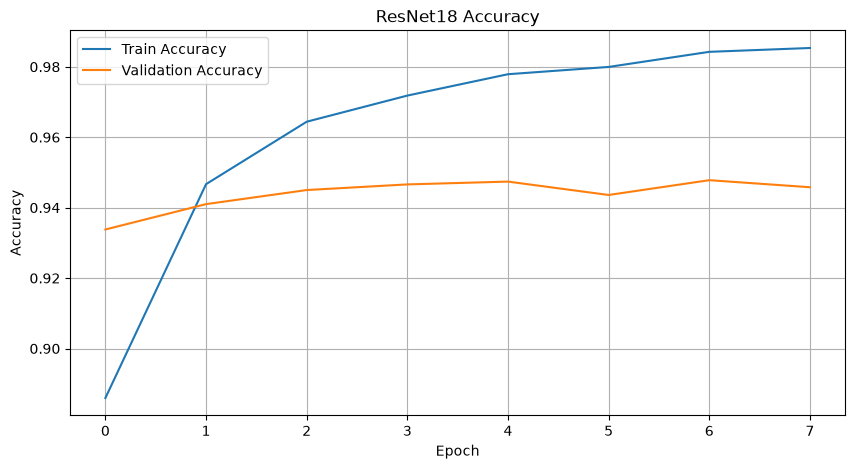

In [48]:
# Training Curves

history_df = pd.DataFrame(history)

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Accuracy")

plt.legend()
plt.grid(True)
plt.show()

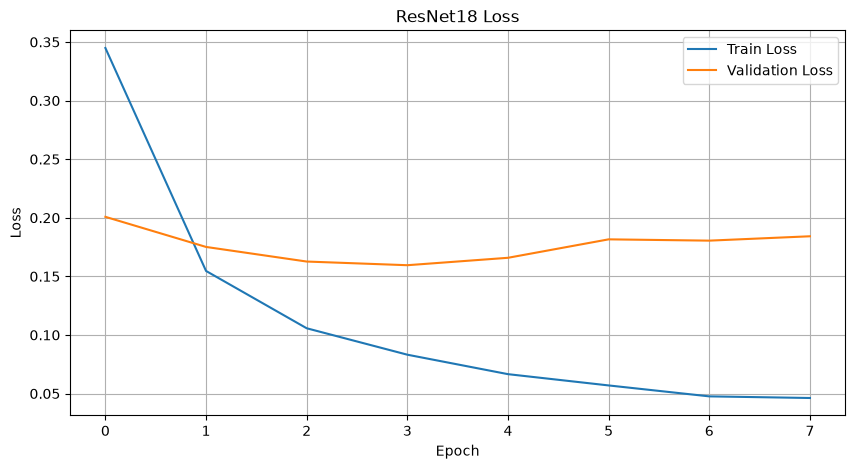

In [49]:
# Loss Curve

plt.figure(figsize=(10, 5))

plt.plot(
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Loss")

plt.legend()
plt.grid(True)
plt.show()

In [50]:
# Test Evaluation

test_loss, test_accuracy, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Test Accuracy:", f"{test_accuracy:.4f}")
print("Precision:", f"{precision:.4f}")
print("Recall:", f"{recall:.4f}")
print("F1 Score:", f"{f1:.4f}")
print(
    "Training Time:",
    f"{training_time / 60:.2f} minutes"
)

Test Accuracy: 0.9436
Precision: 0.9452
Recall: 0.9436
F1 Score: 0.9435
Training Time: 33.23 minutes


In [51]:
# Classification Report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.9418    0.9710    0.9562      1000
  automobile     0.9578    0.9770    0.9673      1000
        bird     0.9547    0.9280    0.9412      1000
         cat     0.8289    0.9250    0.8743      1000
        deer     0.9427    0.9700    0.9561      1000
         dog     0.9557    0.8190    0.8821      1000
        frog     0.9537    0.9690    0.9613      1000
       horse     0.9716    0.9590    0.9653      1000
        ship     0.9652    0.9700    0.9676      1000
       truck     0.9804    0.9480    0.9639      1000

    accuracy                         0.9436     10000
   macro avg     0.9452    0.9436    0.9435     10000
weighted avg     0.9452    0.9436    0.9435     10000



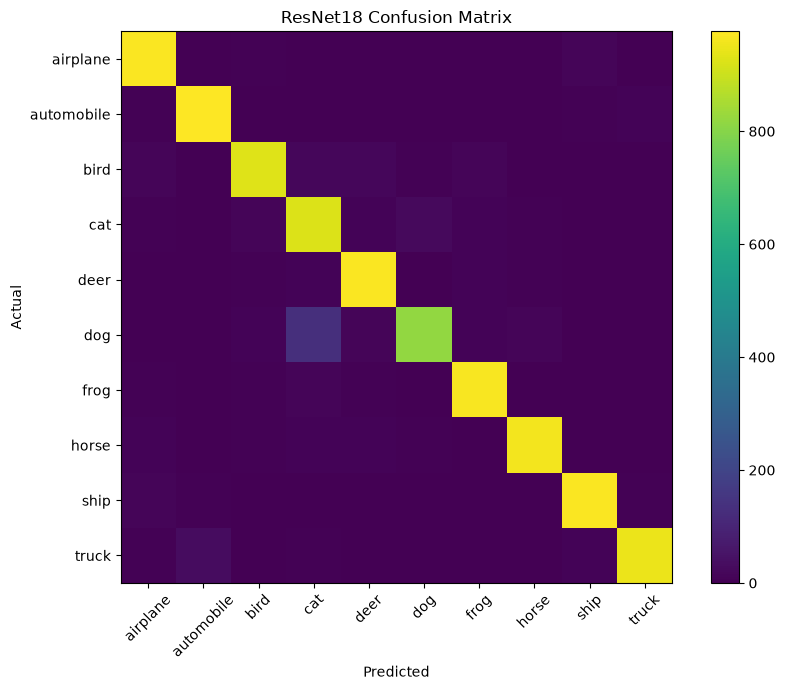

In [52]:
# Confusion Matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [53]:
# Data Efficiency Experiment

def create_subset(
    dataset,
    percentage,
    seed=42
):
    size = int(
        len(dataset) * percentage
    )

    generator = torch.Generator().manual_seed(seed)

    indices = torch.randperm(
        len(dataset),
        generator=generator
    )[:size]

    return Subset(
        dataset,
        indices.tolist()
    )

In [54]:
# Compare Data Sizes

data_percentages = [
    0.25,
    0.50,
    1.00
]

efficiency_results = []

for percentage in data_percentages:

    print("\n" + "=" * 50)
    print(
        f"Using {percentage * 100:.0f}% "
        "of training data"
    )
    print("=" * 50)

    subset = create_subset(
        train_subset,
        percentage,
        SEED
    )

    subset_loader = DataLoader(
        subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    transfer_model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )

    transfer_model.fc = nn.Linear(
        transfer_model.fc.in_features,
        NUM_CLASSES
    )

    transfer_model = transfer_model.to(device)

    optimizer = optim.AdamW(
        transfer_model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    start = time.time()

    best_accuracy = 0

    for epoch in range(EPOCHS):

        train_loss, train_acc = train_one_epoch(
            transfer_model,
            subset_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc, _, _ = evaluate(
            transfer_model,
            val_loader,
            criterion
        )

        best_accuracy = max(
            best_accuracy,
            val_acc
        )

    elapsed = time.time() - start

    _, subset_test_accuracy, _, _ = evaluate(
        transfer_model,
        test_loader,
        criterion
    )

    efficiency_results.append({
        "data_percentage": percentage * 100,
        "training_samples": len(subset),
        "validation_accuracy": best_accuracy,
        "test_accuracy": subset_test_accuracy,
        "training_time_minutes": elapsed / 60
    })

efficiency_df = pd.DataFrame(
    efficiency_results
)

efficiency_df


Using 25% of training data

Using 50% of training data

Using 100% of training data


,data_percentage,training_samples,validation_accuracy,test_accuracy,training_time_minutes
0,25.0,11250,0.9304,0.9095,11.414780
1,50.0,22500,0.9366,0.9378,18.570528
2,100.0,45000,0.9508,0.9460,33.015951


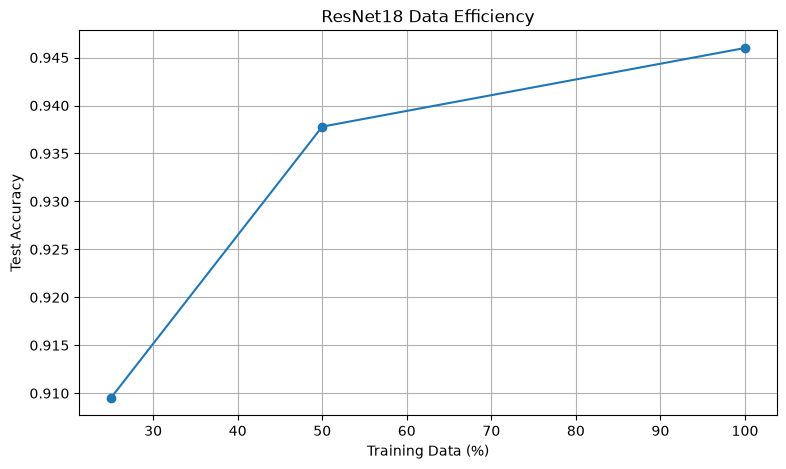

In [55]:
# Data Efficiency Plot

plt.figure(figsize=(9, 5))

plt.plot(
    efficiency_df["data_percentage"],
    efficiency_df["test_accuracy"],
    marker="o"
)

plt.xlabel("Training Data (%)")
plt.ylabel("Test Accuracy")
plt.title("ResNet18 Data Efficiency")

plt.grid(True)
plt.show()

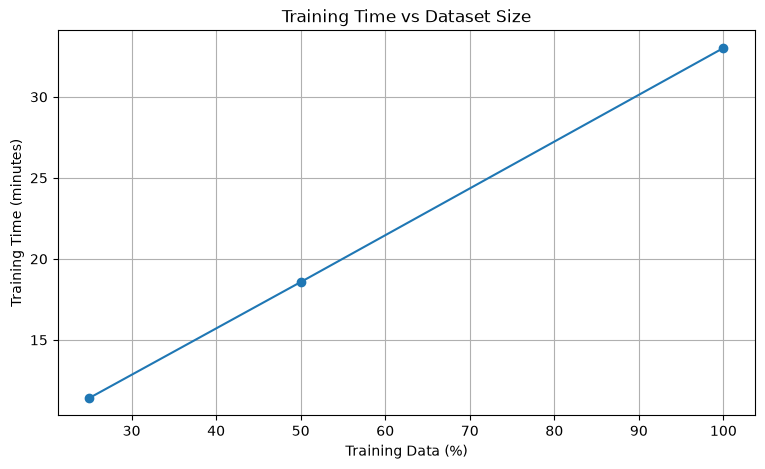

In [56]:
# Training Time Comparison

plt.figure(figsize=(9, 5))

plt.plot(
    efficiency_df["data_percentage"],
    efficiency_df["training_time_minutes"],
    marker="o"
)

plt.xlabel("Training Data (%)")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time vs Dataset Size")

plt.grid(True)
plt.show()

In [57]:
# Save Best Model

MODEL_PATH = (
    "../results/day13_14_resnet18_best.pth"
)

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Model saved:", MODEL_PATH)

Model saved: ../results/day13_14_resnet18_best.pth


In [58]:
# Save Results

transfer_results = pd.DataFrame([{
    "model": "ResNet18 Transfer Learning",
    "test_accuracy": test_accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "training_time_minutes": training_time / 60,
    "total_parameters": total_params,
    "trainable_parameters": trainable_params
}])

transfer_results.to_csv(
    "../results/day13_14_transfer_learning.csv",
    index=False
)

efficiency_df.to_csv(
    "../results/day13_14_data_efficiency.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [59]:
# Compare With From-Scratch CNN

scratch_accuracy = 0.8162
scratch_f1 = 0.8150084829482959
scratch_training_time = 20.7385
scratch_parameters = 806218

comparison_df = pd.DataFrame([
    {
        "Model": "From-Scratch CNN",
        "Accuracy": scratch_accuracy,
        "F1 Score": scratch_f1,
        "Training Time": scratch_training_time,
        "Parameters": scratch_parameters,
        "Pretrained": "No"
    },
    {
        "Model": "ResNet18",
        "Accuracy": test_accuracy,
        "F1 Score": f1,
        "Training Time": training_time / 60,
        "Parameters": total_params,
        "Pretrained": "Yes"
    }
])

comparison_df

,Model,Accuracy,F1 Score,Training Time,Parameters,Pretrained
0,From-Scratch CNN,0.8162,0.815008,20.738500,806218,No
1,ResNet18,0.9436,0.943525,33.234043,11181642,Yes


In [60]:
# Final Observations

print("Transfer Learning Results")
print("-------------------------")

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"F1 Score: {f1:.4f}"
)

print(
    f"Training Time: "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Total Parameters: "
    f"{total_params:,}"
)

print("\nData Efficiency Results:")
print(efficiency_df)

Transfer Learning Results
-------------------------
Test Accuracy: 0.9436
F1 Score: 0.9435
Training Time: 33.23 minutes
Total Parameters: 11,181,642

Data Efficiency Results:
   data_percentage  training_samples  validation_accuracy  test_accuracy  \
0             25.0             11250               0.9304         0.9095   
1             50.0             22500               0.9366         0.9378   
2            100.0             45000               0.9508         0.9460   

   training_time_minutes  
0              11.414780  
1              18.570528  
2              33.015951  
